## Script to generate figure 4


In [97]:

import numpy as np
import pandas as pd
import matplotlib 
from scipy import stats
import matplotlib.pyplot as plt
from itertools import product
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [98]:
df = pd.read_csv('../data_final_push_2.csv')
#df2 = pd.read_csv('../data_final_push.csv')
#fuse the two dataframes
#df = pd.concat([df, df2], ignore_index=True)


pd.set_option('display.max_columns', None)

df["goal_improvement"] = df["maxed_goal_value"] - df["goal_base"]
df["delta_opti_goal"] = df["optimal_goal_value"] - df["goal_base"]
df["correlation_diff"] = df['correlation_on_max_proxy'] -  df['correlation_base'] 
df["proxy_improvement"] = df["maxed_proxy_value"] - df["proxy_base"]
df["D"] = df['goal_discard'] - df["proxy_discard"]
df['E'] = df["avg_number_of_edges"]
df['S'] = df["spectral_radius"]
df['N'] = df["n"]

sub_df = df[df["correlation_diff"].notna()]  ## It is normal that some 
sub_df.describe()

# create a new data base that groups collumns based of the parameters D E S N
unic = []
weak = False
param_list = ['D',"E","S","N"]
option_list = ['strong','weak','benign','proxy_failure','DeltaProx','DeltaGoal','DeltaCorr']

for k in param_list:
    unic.append( df[k].unique())

param_combinations = list(product(unic[0],unic[1],unic[2],unic[3] ))

param_end = list(product(unic[0], unic[1]))
param_end_range = range(len(param_end))
com_min = len(param_list)
com_max = sum([len(unic[i]) for i in range(len(param_list))])
    
Ms = {option_list[i]:np.zeros((len(unic[0]),len(unic[1]),len(unic[2]), len(unic[3]))) for i in range(len(option_list))}

Y = [[[] for j in range(com_min, com_max+1)] for k in range(len(option_list))] # failure, benign, weak, strong 
for k in range(len(param_combinations)):
    (p0,p1, p2,p3)= param_combinations[k]
    ranks = [unic[i].tolist().index(param_combinations[k][i]) for i in range(4)]
    subsub_df = df[(df[param_list[0]] == p0) & (df[param_list[1]] == p1) &(df[param_list[2]] == p2) &(df[param_list[3]] == p3)]
    complexity_class = sum([1+unic[i].tolist().index(param_combinations[k][i]) for i in range(4)])
    total = len(subsub_df)
    proxy_failure_df = subsub_df[(subsub_df["correlation_diff"] < 0)]

    
    
    prop_failure_prox = len(proxy_failure_df ) / total
    prop_failure_strong = len(proxy_failure_df[proxy_failure_df["goal_improvement"] < 0]) / total

    temp_weakdf = proxy_failure_df[proxy_failure_df["goal_improvement"] > 0]
    prop_failure_weak = len(temp_weakdf[temp_weakdf["proxy_improvement"] > temp_weakdf["goal_improvement"]]) / total
    prop_failure_benign = len(proxy_failure_df[proxy_failure_df["proxy_improvement"] < proxy_failure_df["goal_improvement"] ]) / total

    DeltaProx = np.mean(subsub_df["proxy_improvement"])
    DeltaGoal = np.mean(subsub_df["goal_improvement"])
    DeltaCorr = np.mean(subsub_df["correlation_diff"])

    Ms['proxy_failure'][ranks[0], ranks[1], ranks[2], ranks[3]] = prop_failure_prox
    Ms['strong'][ranks[0], ranks[1], ranks[2], ranks[3]] = prop_failure_strong
    Ms['weak'][ranks[0], ranks[1], ranks[2], ranks[3]] = prop_failure_weak
    Ms['benign'][ranks[0], ranks[1], ranks[2], ranks[3]] = prop_failure_benign
    Ms['DeltaProx'][ranks[0], ranks[1], ranks[2], ranks[3]] = DeltaProx
    Ms['DeltaGoal'][ranks[0], ranks[1], ranks[2], ranks[3]] = DeltaGoal
    Ms['DeltaCorr'][ranks[0], ranks[1], ranks[2], ranks[3]] = DeltaCorr

    for i in range(len(option_list)):
        Y[i][complexity_class-com_min].append(Ms[option_list[i]][ranks[0], ranks[1], ranks[2], ranks[3]])
# turn Y into a numpy array
def sem_pop(L):
    p = np.mean(L)
    q = 1-p
    return (p*q/len(L))**0.5

Yerr = np.array([[np.std(Y[i][j]) for j in range(13)] for i in range(7)])

In [99]:
titles = {
    "proxy_failure": 'Proportion of proxy failure\n'r'$(\Delta R < 0)$',
    "strong": 'Proportion of strong proxy failure\n'r'$(\Delta R < 0 \cap \Delta G < 0)$',
    "weak": 'Proportion of weak proxy failure\n'r'$(\Delta R < 0, \Delta R > \Delta G > 0)$',
    "benign": 'Proportion of benign proxy failure\n'r'$(\Delta R < 0, \Delta G > \Delta R > 0)$',
    "DeltaProx": 'Mean proxy improvement\n'r'$(\Delta R)$',
    "DeltaGoal": 'Mean goal improvement\n'r'$(\Delta G)$',
    "DeltaCorr": 'Mean correlation improvement\n'r'$(\Delta R_{corr})$'
}
titles

{'proxy_failure': 'Proportion of proxy failure\n$(\\Delta R < 0)$',
 'strong': 'Proportion of strong proxy failure\n$(\\Delta R < 0 \\cap \\Delta G < 0)$',
 'weak': 'Proportion of weak proxy failure\n$(\\Delta R < 0, \\Delta R > \\Delta G > 0)$',
 'benign': 'Proportion of benign proxy failure\n$(\\Delta R < 0, \\Delta G > \\Delta R > 0)$',
 'DeltaProx': 'Mean proxy improvement\n$(\\Delta R)$',
 'DeltaGoal': 'Mean goal improvement\n$(\\Delta G)$',
 'DeltaCorr': 'Mean correlation improvement\n$(\\Delta R_{corr})$'}

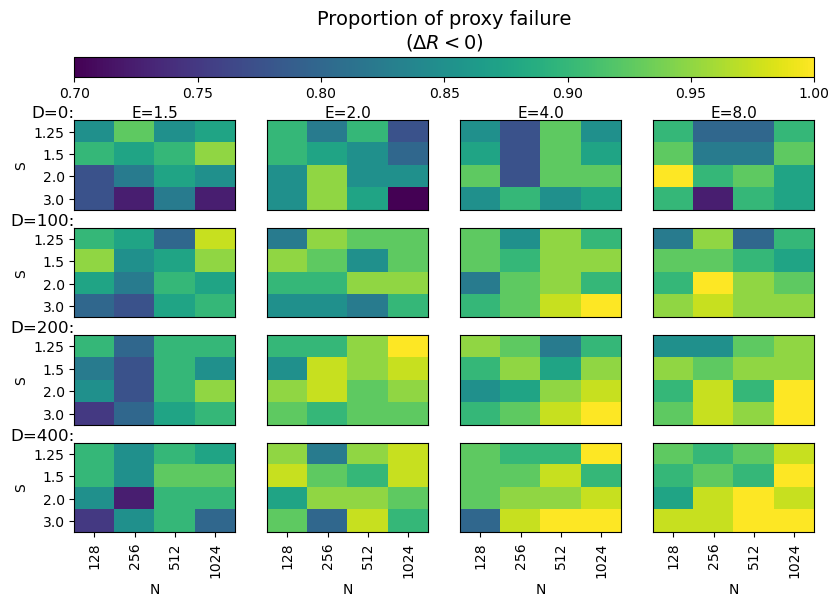

In [103]:
def plot_heatMap(gsCro,fig, df, param1, param2, param3, param4, option, right = True, cmincmax = None):
    ''' find all possible values of param1 and param2 in the dataframe df
        then for each combination of param1 and param2, make a scatter plot along the other two parameters
        and color the points according to param_for_color
    '''
    param1_values = df[param1].unique()
    param2_values = df[param2].unique()
    param3_values = df[param3].unique() 
    param4_values = df[param4].unique()
    len_vals = [len(param1_values), len(param2_values), len(param3_values), len(param4_values)]

    lex = len(param1_values.tolist())
    ley = len(param2_values.tolist())
    cm = 1/2.54
    param_combinations = list(product(param1_values, param2_values))
    outer = gridspec.GridSpecFromSubplotSpec(2,1, height_ratios=[1,20], subplot_spec=gsCro)

    gs00 = gridspec.GridSpecFromSubplotSpec(lex, ley, subplot_spec=outer[1])
    #search for the maximum and minimum of param_for_color
    param_range = range(len(param_combinations))
    axes = []
    
    

    cmap = 'viridis'
    if option == "DeltaCorr":
        cmap = 'inferno_r'
    for k in param_range:
        x,y = k//lex , k%lex
        axes.append(fig.add_subplot(gs00[x, y]))
    
    indexp1 = param_list.index(param1)
    indexp2 = param_list.index(param2)

    if cmincmax:
        cmin, cmax = cmincmax
    else:
        cmax = np.max(Ms[option])
        cmin = np.min(Ms[option])
    
    for i in range(len(param1_values)):
        for j in range(len(param2_values)):
            
            (p1, p2 )= param1_values[i], param2_values[j]
            
            ax = axes[i*lex + j]
            ax.grid(False)
            entry = [[k for k in range(len_vals[m])] for m in range(4)]
            entry[indexp1] = [i]
            entry[indexp2] = [j]

            c = ax.imshow(Ms[option][np.ix_(*entry)][0][0], origin='lower', vmin=cmin, vmax=cmax, cmap=cmap, aspect='auto')

            #ax.scatter(grouped[param3], grouped[param4], alpha = 0.7, color = plt.cm.viridis((grouped[param_for_color] - min_color) / (max_color - min_color)))
            
            ax.set_xticks([])
            ax.set_yticks([])
            
            if param2_values.tolist().index(p2) == 0 and right :
                ax.set_ylabel(param3)
                ax.set_yticks([0,1,2,3],param3_values) 

                ax.text(0.0, 1.08, f'{param1}={p1}:', fontsize=12, horizontalalignment = "right", verticalalignment = "center", transform=ax.transAxes)
                if param1_values.tolist().index(p1) == 0:
                    ax.set_title(f'{param2}={p2}', fontsize = 11, loc='center', pad = -5)
            elif param1_values.tolist().index(p1) == 0:
                ax.set_title(f'{param2}={p2}', fontsize = 11, loc='center', pad = -5)
            if param1_values.tolist().index(p1) == len(param1_values)-1:
                ax.set_xlabel(param4)
                ax.set_xticks([0,1,2,3],param4_values,rotation=90)
            ax.invert_yaxis()
            




    # add a common colorbar between the maximum and minimum of param_for_color
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=cmin, vmax=cmax))
    sm.set_array([])
    cax =  fig.add_subplot(outer[0])
    fig.add_axes(cax)
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
    cax.set_title(titles[option], fontsize = 14)
    #cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation='vertical', pad = 500)

    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42

fig = plt.figure(figsize=(21, 21))
gs = gridspec.GridSpec(3, 2, figure=fig)
plot_heatMap(gs[0,0], fig, df, 'D', 'E', 'S', 'N', "proxy_failure")


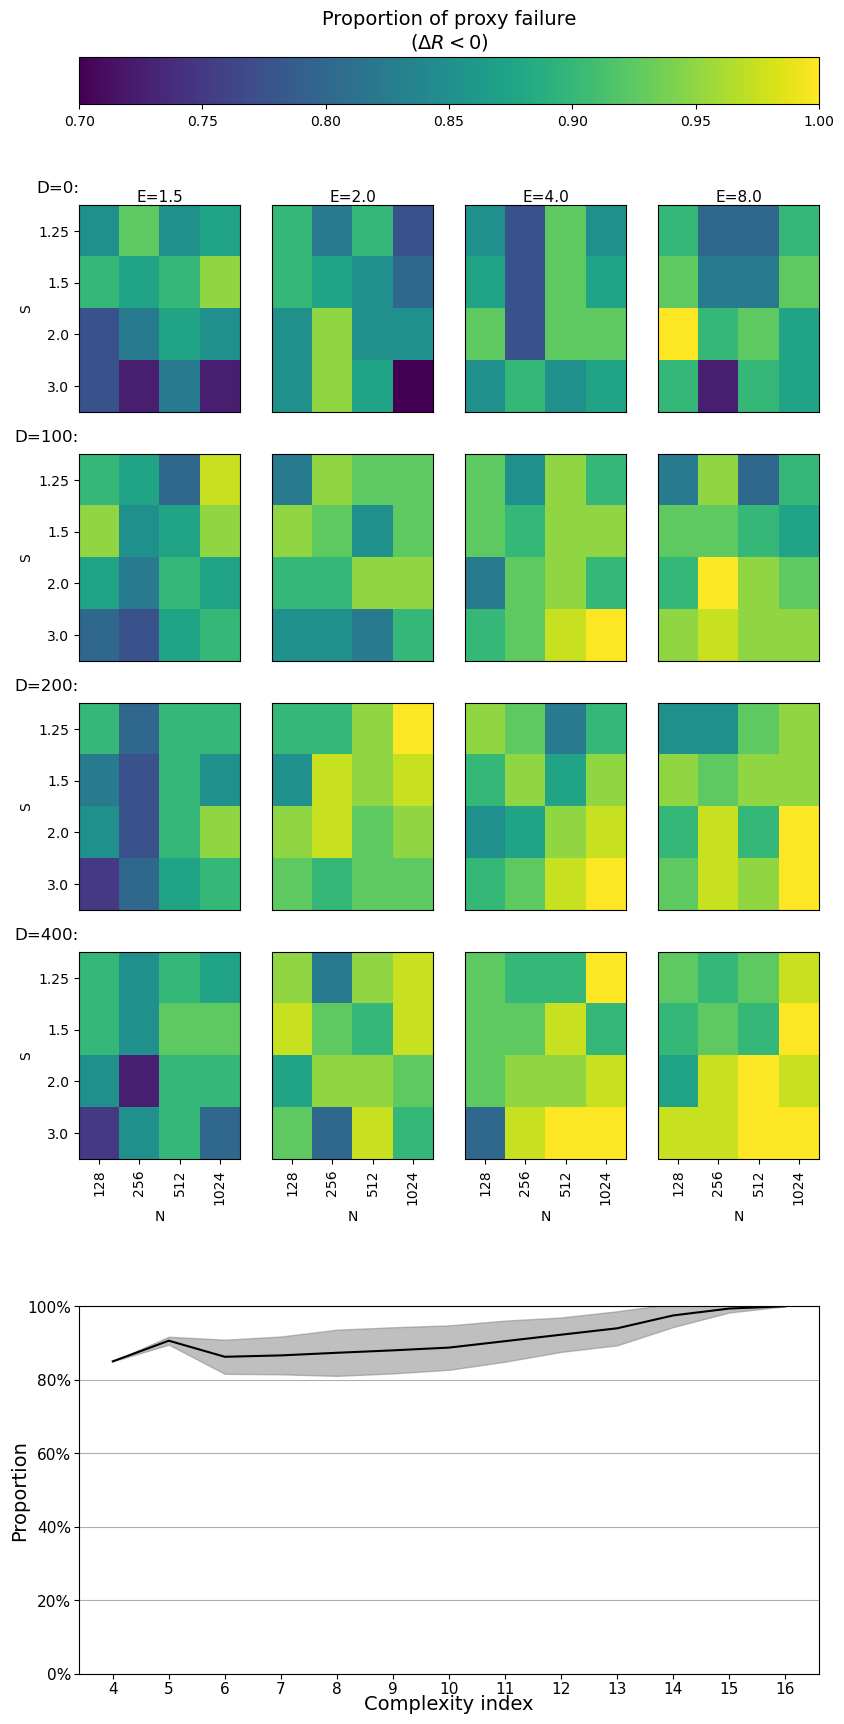

In [ ]:

def yAll(isDelta, ax):
    if isDelta:
        ax.set_ylabel('Mean value', fontsize = 14, labelpad=-1)
        ax.set_yticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6], ['-0.6', '-0.4', '-0.2', '0', '0.2', '0.4', '0.6'], fontsize = 11)
    else:
        ax.set_yticks([0,0.2,0.4,0.6,0.8,1], ['0%','20%','40%','60%','80%','100%'], fontsize = 11)
        ax.set_ylabel('Proportion', fontsize = 14, labelpad=-1)

def make_snake(gs,option, right = True):
    k = option_list.index(option)
    Xes = range(4,17)
    Xlab = [str(i+4) for i in range(13)]
    ax = fig.add_subplot(gs)
    Y_mean = np.array([np.mean(Y[k][j]) for j in range(13)])
    ax.fill_between(Xes, Y_mean - Yerr[k],  Y_mean + Yerr[k], color='gray', alpha=0.5)
    ax.plot(Xes, Y_mean, color = 'k')
    ax.set_xlabel('Complexity index', fontsize = 14, labelpad=-1)
    
    

    if option in ["DeltaProx", "DeltaGoal", "DeltaCorr"]:
        isDelta = True
        ax.set_ylim(-0.6,0.6)
        ax.set_yticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6], ['']*7, fontsize = 11)
    else:
        isDelta = False
        ax.set_ylim(0,1)
        ax.set_yticks([0,0.2,0.4,0.6,0.8,1], ['']*6, fontsize = 11)
    if right:
        yAll(isDelta, ax)
    ax.yaxis.grid(True)
    ax.xaxis.grid(False)
    ax.tick_params(axis='y', which='major', pad=2)
    ax.tick_params(axis='x', which='major', pad=2)
    ax.set_xticks(Xes, labels = Xlab, fontsize = 11)
    


fig = plt.figure(figsize=(21, 21))
gs = gridspec.GridSpec(2, 2, height_ratios=(3,1), figure=fig)
plot_heatMap(gs[0,0], fig, df, 'D', 'E', 'S', 'N', "proxy_failure", filename= "Matrixstrongproxyfailure")
make_snake(gs[1,0], "proxy_failure")




## Full figure now

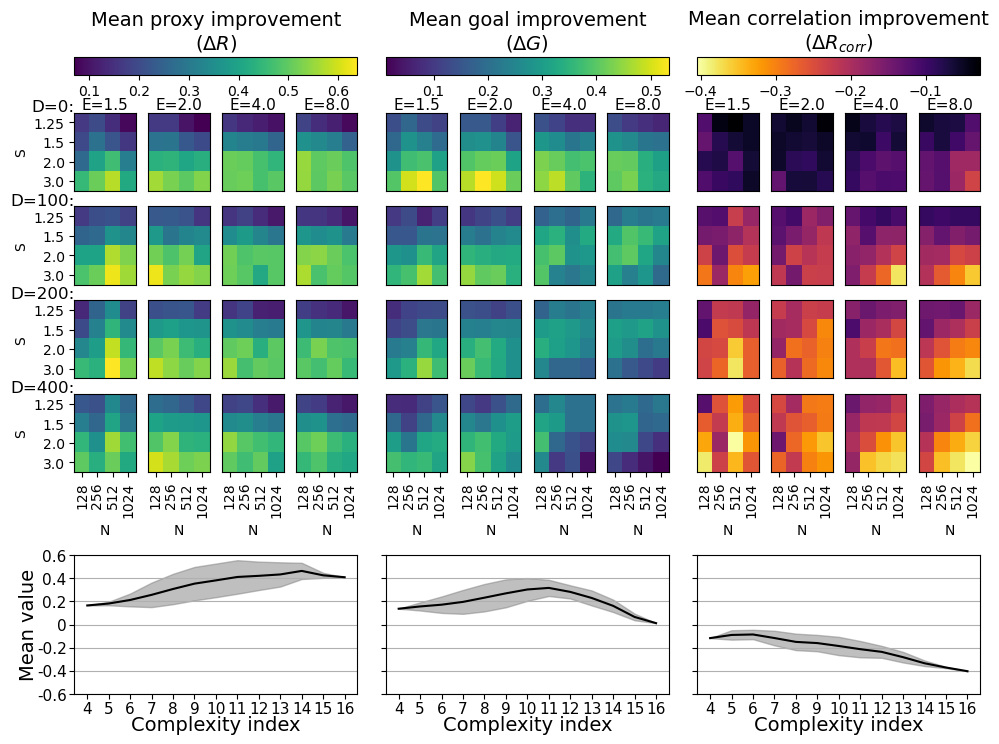

In [ ]:

fig = plt.figure( figsize =(11.69,8.27))

options_fig = ['DeltaProx', 'DeltaGoal', 'DeltaCorr']
gs = gridspec.GridSpec(2, len(options_fig), height_ratios=(3,1), figure=fig, wspace=0.1, hspace=0.3)

for k in range(len(options_fig)):
    right = k ==0
    plot_heatMap(gs[0,k], fig, df, 'D', 'E', 'S', 'N', options_fig[k], right=right)
    make_snake(gs[1,k], options_fig[k], right=right)



plt.savefig("figures_output/fig4.svg", format="svg", transparent=True)




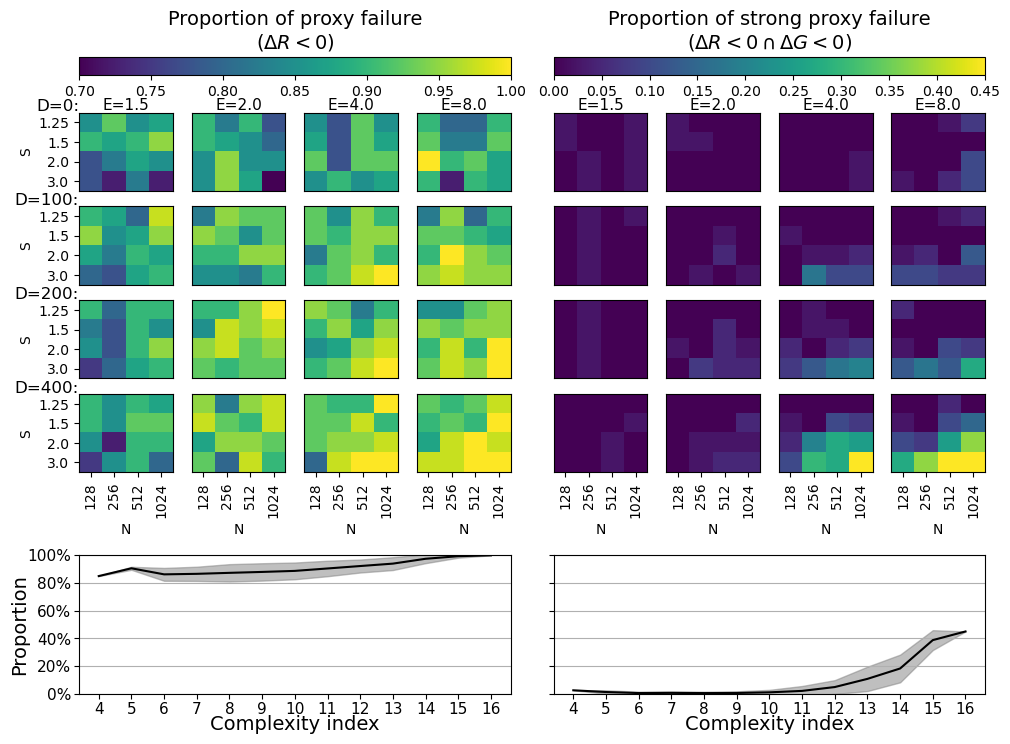

In [ ]:

fig = plt.figure( figsize =(11.69,8.27))

options_fig = ['proxy_failure','strong']
gs = gridspec.GridSpec(2, len(options_fig), height_ratios=(3,1), figure=fig, wspace=0.1, hspace=0.3)

for k in range(len(options_fig)):
    right = k ==0
    plot_heatMap(gs[0,k], fig, df, 'D', 'E', 'S', 'N', options_fig[k], right=right)
    make_snake(gs[1,k], options_fig[k], right=right)


plt.savefig("figures_output/fig5.svg", format="svg", transparent=True)


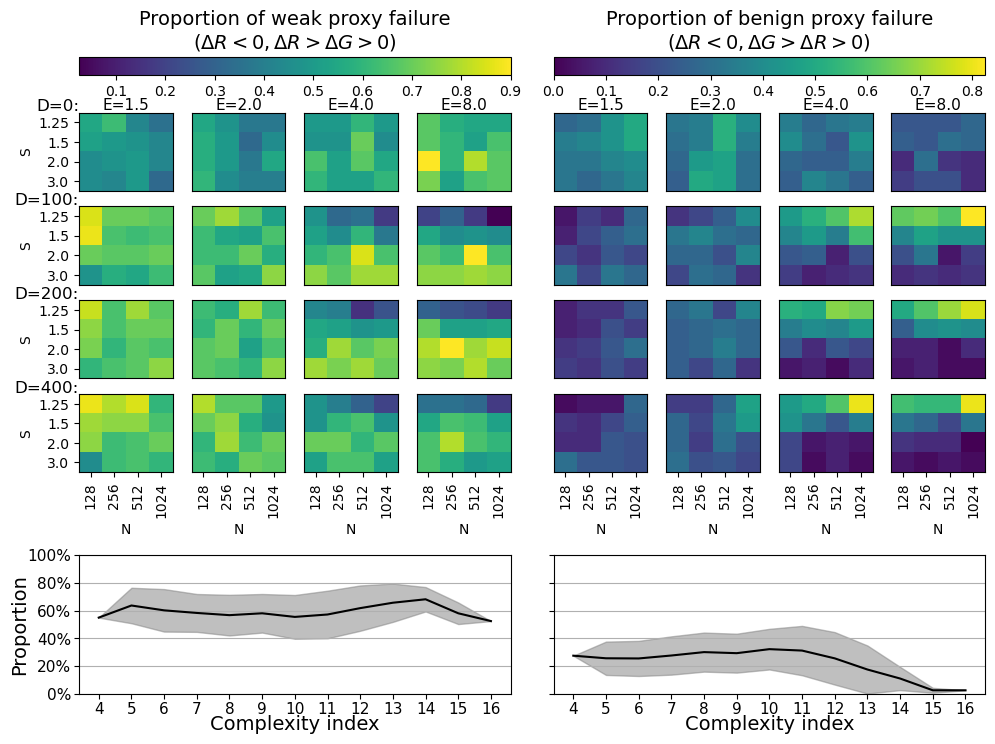

In [105]:

fig = plt.figure( figsize =(11.69,8.27))

options_fig = ['weak','benign']
gs = gridspec.GridSpec(2, len(options_fig), height_ratios=(3,1), figure=fig, wspace=0.1, hspace=0.3)

for k in range(len(options_fig)):
    right = k ==0
    plot_heatMap(gs[0,k], fig, df, 'D', 'E', 'S', 'N', options_fig[k], right=right)
    make_snake(gs[1,k], options_fig[k], right=right)



plt.savefig("figures_output/fig5.svg", format="svg", transparent=True)


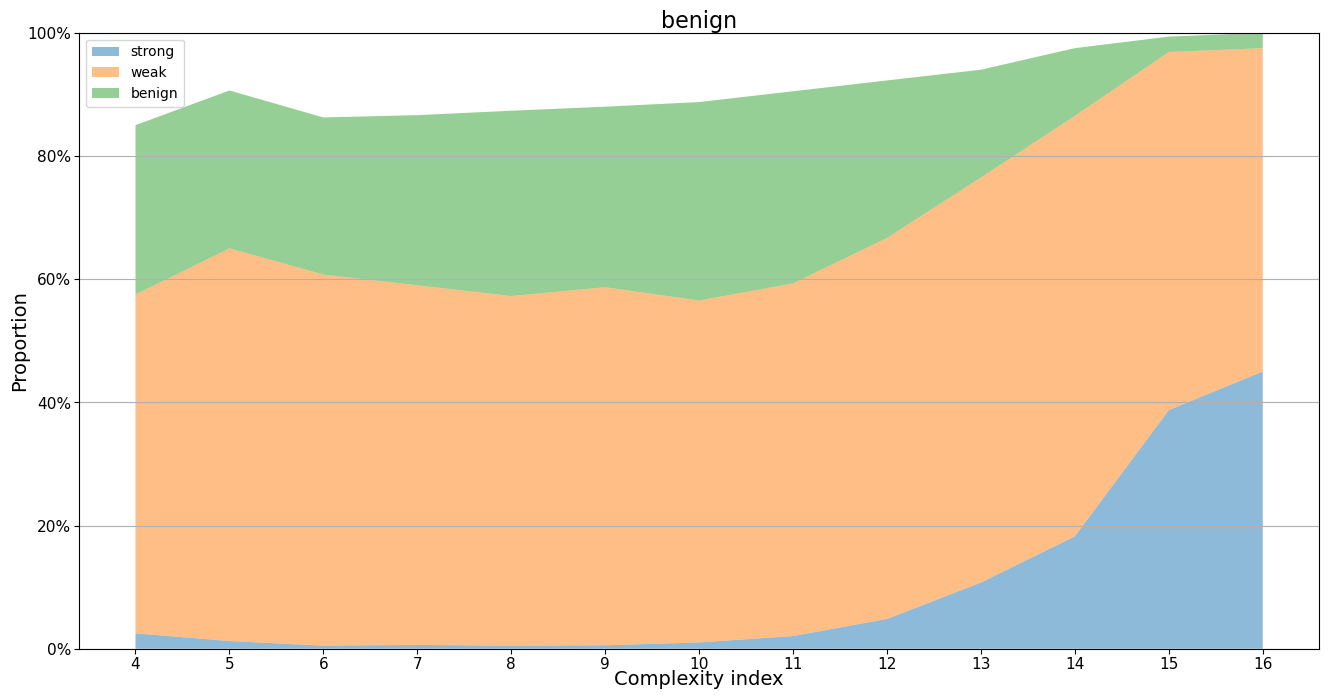

In [ ]:

fig, axs = plt.subplots(1,1, figsize=(16,8))
Xes = range(4,17)
names = option_list
Xlab = [str(i+4) for i in range(13)]
list_prev = np.asarray([0 for k in range(13)])
for k in range(0,3):
    j = 0
    ax = axs
    ax.yaxis.grid(True)
    ax.xaxis.grid(False)
    Y_mean = np.array([np.mean(Y[k][j]) for j in range(13)])
    #
    ax.fill_between(Xes, list_prev,  Y_mean + list_prev, alpha=0.5, label = names[k])
    list_prev = Y_mean + list_prev
    #ax.plot(Xes, Y_mean, label = names[k])
    ax.set_xlabel('Complexity index', fontsize = 14, labelpad=-1)
    ax.set_title(names[k], fontsize = 16,pad=2 )
    ax.set_ylim(0,1)
    ax.set_yticks([0,0.2,0.4,0.6,0.8,1], ['0%','20%','40%','60%','80%','100%'], fontsize = 11)
    ax.tick_params(axis='y', which='major', pad=2)
    ax.tick_params(axis='x', which='major', pad=2)
    ax.set_xticks(Xes, labels = Xlab, fontsize = 11)
    ax.set_yticks([0,0.2,0.4,0.6,0.8,1], ['']*6, fontsize = 11)
    if j == 0:
        ax.set_ylabel('Proportion', fontsize = 14, labelpad=-1)
        ax.set_yticks([0,0.2,0.4,0.6,0.8,1], ['0%','20%','40%','60%','80%','100%'], fontsize = 11)
    ax.legend()

    #ax.legend(fontsize = 11, loc = 'upper left', bbox_to_anchor=(-0.005,1.03), borderpad=0,labelspacing=0.1, handlelength=1, handletextpad=0.5)
fig.savefig("figures_output/XcomplexProbafailure.svg", bbox_inches='tight', dpi=300)

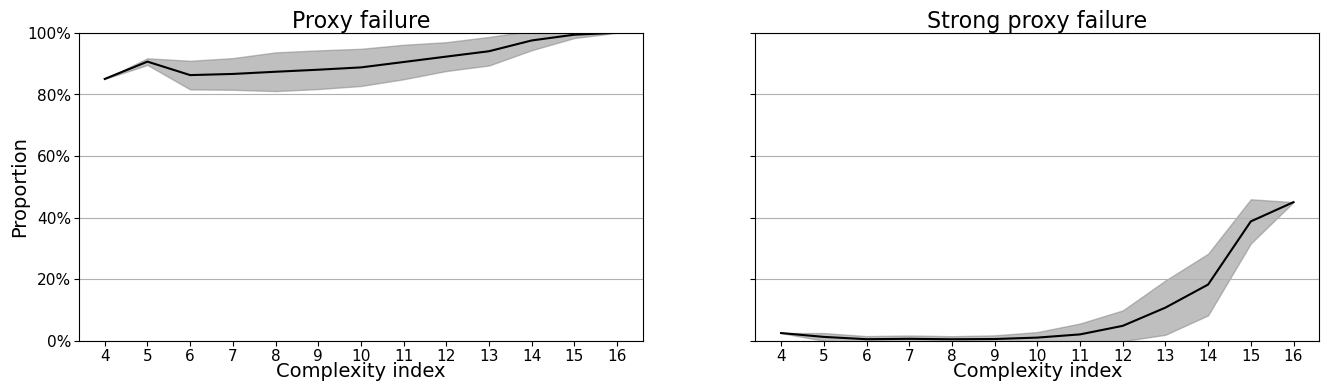

In [ ]:

fig, axs = plt.subplots(1,2, figsize=(16,4))
Xes = range(4,17)
names = ["Proxy failure","Strong proxy failure"]
Xlab = [str(i+4) for i in range(13)]
for k in [0,3]:
    j = 1-k//3
    ax = axs[j]
    ax.yaxis.grid(True)
    ax.xaxis.grid(False)
    Y_mean = np.array([np.mean(Y[k][j]) for j in range(13)])
    ax.fill_between(Xes, Y_mean - Yerr[k],  Y_mean + Yerr[k], color='gray', alpha=0.5)
    ax.plot(Xes, Y_mean, color = 'k')
    ax.set_xlabel('Complexity index', fontsize = 14, labelpad=-1)
    ax.set_title(names[j], fontsize = 16,pad=2 )
    ax.set_ylim(0,1)
    ax.set_yticks([0,0.2,0.4,0.6,0.8,1], ['0%','20%','40%','60%','80%','100%'], fontsize = 11)
    ax.tick_params(axis='y', which='major', pad=2)
    ax.tick_params(axis='x', which='major', pad=2)
    ax.set_xticks(Xes, labels = Xlab, fontsize = 11)
    ax.set_yticks([0,0.2,0.4,0.6,0.8,1], ['']*6, fontsize = 11)
    if j == 0:
        ax.set_ylabel('Proportion', fontsize = 14, labelpad=-1)
        ax.set_yticks([0,0.2,0.4,0.6,0.8,1], ['0%','20%','40%','60%','80%','100%'], fontsize = 11)

    #ax.legend(fontsize = 11, loc = 'upper left', bbox_to_anchor=(-0.005,1.03), borderpad=0,labelspacing=0.1, handlelength=1, handletextpad=0.5)
fig.savefig("figures_output/fig4.pdf", bbox_inches='tight', dpi=300)

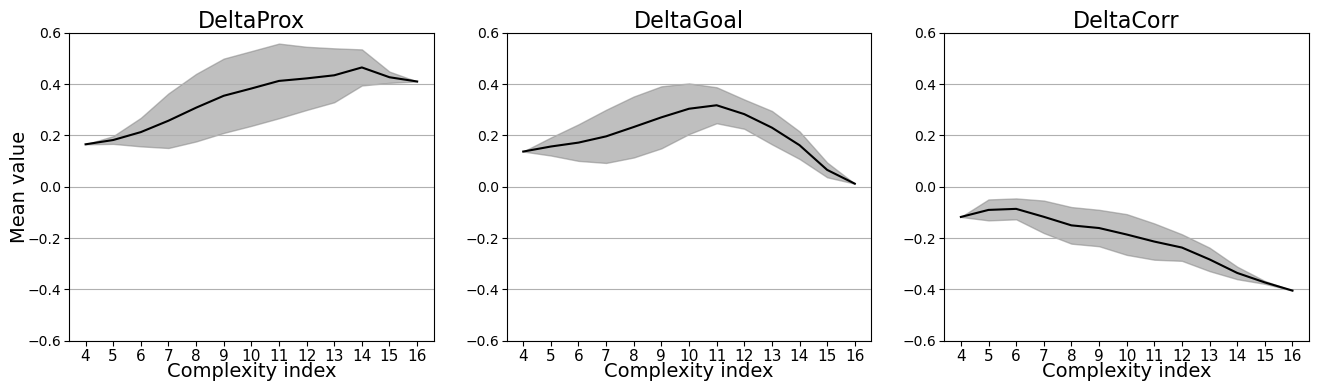

In [ ]:

fig, axs = plt.subplots(1,3, figsize=(16,4))
Xes = range(4,17)
names = option_list
Xlab = [str(i+4) for i in range(13)]
for k in range(4,7):
    j = k-4
    ax = axs[j]
    ax.yaxis.grid(True)
    ax.xaxis.grid(False)
    Y_mean = np.array([np.mean(Y[k][j]) for j in range(13)])
    #
    ax.fill_between(Xes, Y_mean - Yerr[k],  Y_mean + Yerr[k], color='gray', alpha=0.5, label = names[k])
    ax.plot(Xes, Y_mean, color = 'k')
    ax.set_xlabel('Complexity index', fontsize = 14, labelpad=-1)
    ax.set_title(names[k], fontsize = 16,pad=2 )
    ax.set_ylim(-0.6,0.6)

    ax.tick_params(axis='y', which='major', pad=2)
    ax.tick_params(axis='x', which='major', pad=2)
    ax.set_xticks(Xes, labels = Xlab, fontsize = 11)
    if j == 0:
        ax.set_ylabel('Mean value', fontsize = 14, labelpad=-1)

    #ax.legend(fontsize = 11, loc = 'upper left', bbox_to_anchor=(-0.005,1.03), borderpad=0,labelspacing=0.1, handlelength=1, handletextpad=0.5)
fig.savefig("figures_output/XcomplexMeans.svg", bbox_inches='tight', dpi=300)

In [ ]:
max(1, None)

TypeError: '>' not supported between instances of 'NoneType' and 'int'